In [1]:
import ase.units
import numpy as np
import matplotlib.pyplot as plt

# Read Experimental Data
import pandas as pd

In [2]:
lines = []

with open('ZnO.freq.gp') as f:
    for line in f:
        if line.strip() and not line.startswith('#'):
            lines.append(line)

data = np.loadtxt(lines)

q = data[:,0]
freqs = data[:,1:]


<h2> Referências </h2>

## meV reference.
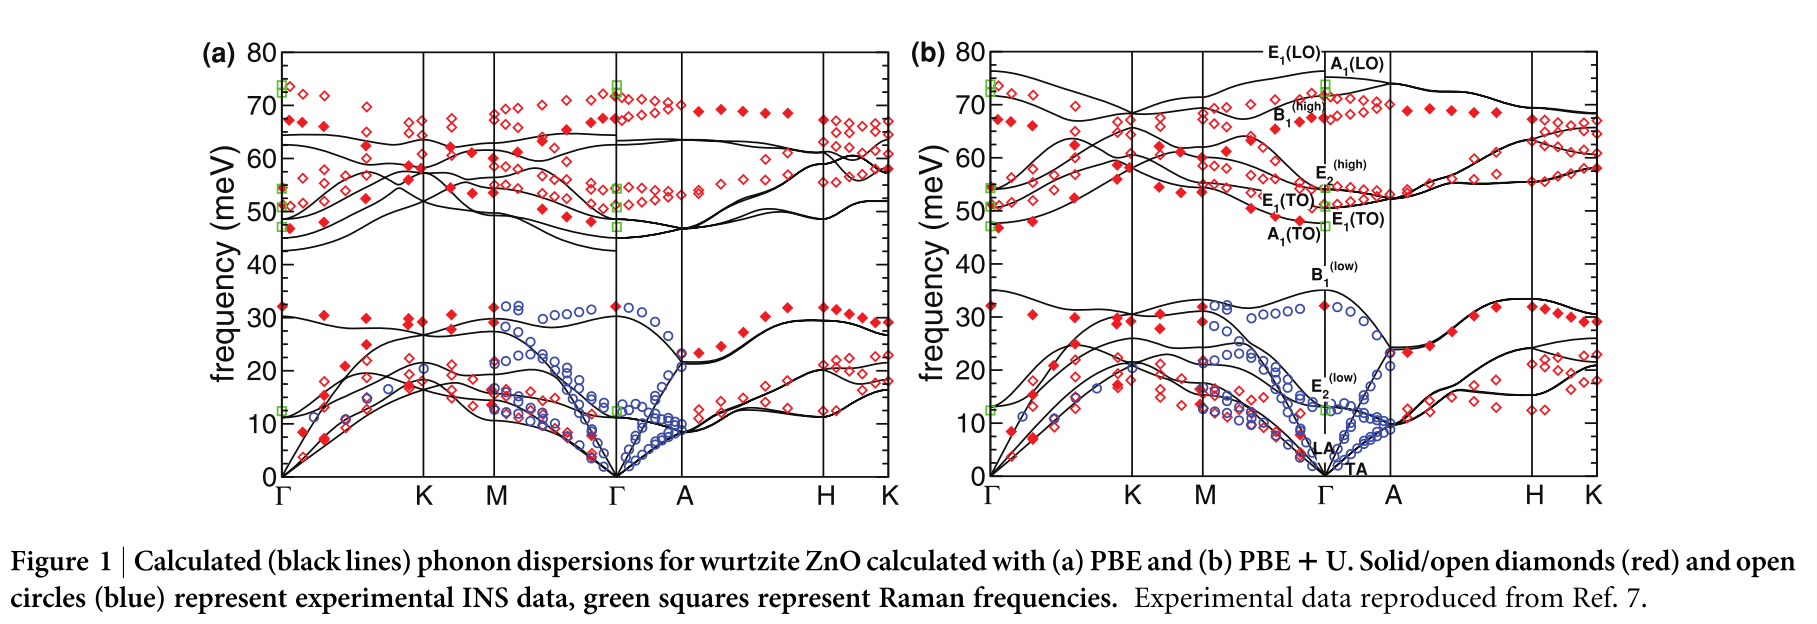


## THz reference

<div align="center" >

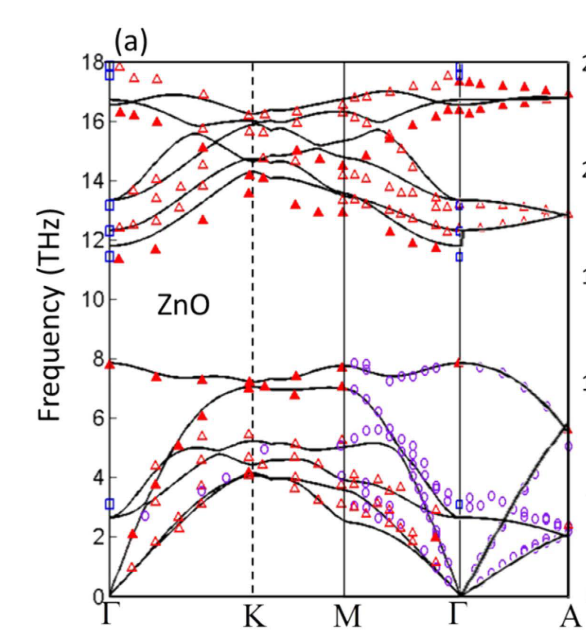

</div>

<div align="center">

| Unidade      | Símbolo | Conversão |
| ------------ | ------- | --------- |
| 1 THz → cm⁻¹ |         | 33.35641  |
| 1 THz → meV  |         | 4.13567   |
| 1 cm⁻¹ → meV |         | 0.123984  |
| 1 meV → THz  |         | 0.24180   |
| 1 cm⁻¹ → THz |         | 0.029979  |

</div>

In [11]:
# Conversão unidades
invcm_to_THz = 0.029979
invcm_to_meV = ase.units.invcm * 1_000

# THz
freqs_THz = freqs * invcm_to_THz

# meV
freqs_meV = freqs * invcm_to_meV 

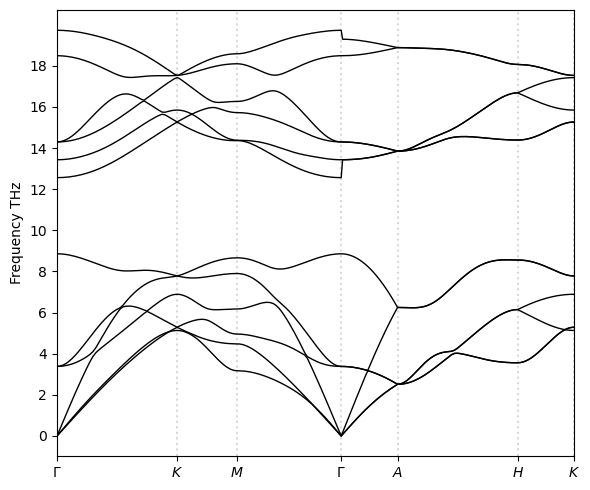

In [12]:

# PLOTTING
plt.figure(figsize=(6,5))

# Labels 
high_symmetry_points = [q[40*i] for i in range(7)]
for hsp in high_symmetry_points:
    plt.axvline(hsp, c='gray', alpha=0.3, ls=':')
plt.xticks(
    ticks = high_symmetry_points,
    labels= [r"$\Gamma$", r"$K$", r"$M$", r"$\Gamma$", r"$A$", r"$H$", r"$K$"]
)
plt.yticks(ticks= [i for i in range(0, 20, 2)] )

for i in range(freqs.shape[1]):
    plt.plot(q, freqs_THz[:,i], lw=1, color='k')

# plt.axhline(0, lw=0.5)
plt.ylabel("Frequency THz")
plt.xlabel('')
plt.xlim(high_symmetry_points[0], high_symmetry_points[-1])

plt.tight_layout()
plt.show()

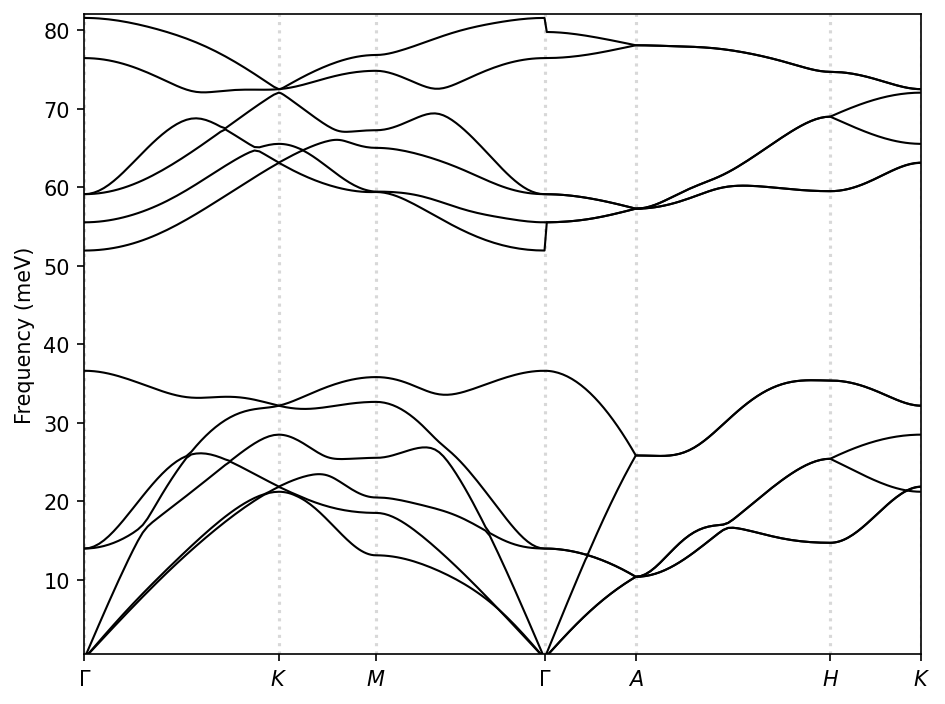

In [18]:
plt.figure(dpi=150)

# Labels 
high_symmetry_points = [q[40*i] for i in range(7)]
for hsp in high_symmetry_points:
    plt.axvline(hsp, c='gray', alpha=0.3, ls=':')
plt.xticks(
    ticks = high_symmetry_points,
    labels= [r"$\Gamma$", r"$K$", r"$M$", r"$\Gamma$", r"$A$", r"$H$", r"$K$"]
)
# plt.yticks(ticks= [i for i in range(0, 90, 10)] )

for i in range(freqs_meV.shape[1]):
    plt.plot(q, freqs_meV[:,i], lw=1, color='k')


# plt.axhline(0, lw=0.5)
plt.ylabel("Frequency (meV)")
plt.xlabel('')
plt.xlim(high_symmetry_points[0], high_symmetry_points[-1])
plt.ylim([0.5, np.max(freqs_meV)+0.5])
plt.tight_layout()
plt.show()

In [19]:
! ls experimental-data/

expdata_green_squares.csv  expdata_purple_circles.csv  expdata_red_squares.csv


In [4]:
df_red = pd.read_csv('experimental-data/expdata_red_squares.csv', names=['k', 'freq_meV'] , delimiter= ';')
df_purple = pd.read_csv('experimental-data/expdata_purple_circles.csv', names=['k', 'freq_meV'] , delimiter= ';')
df_green = pd.read_csv('experimental-data/expdata_green_squares.csv', names=['k', 'freq_meV'] , delimiter= ';')

<h3> Comparação com dados experimentais </h3>

In [7]:
! ls /home/jvc/QEspresso7.2/ZnO_database/mpl_themes

computermodern.mplstyle  scientific_plot.mplstyle


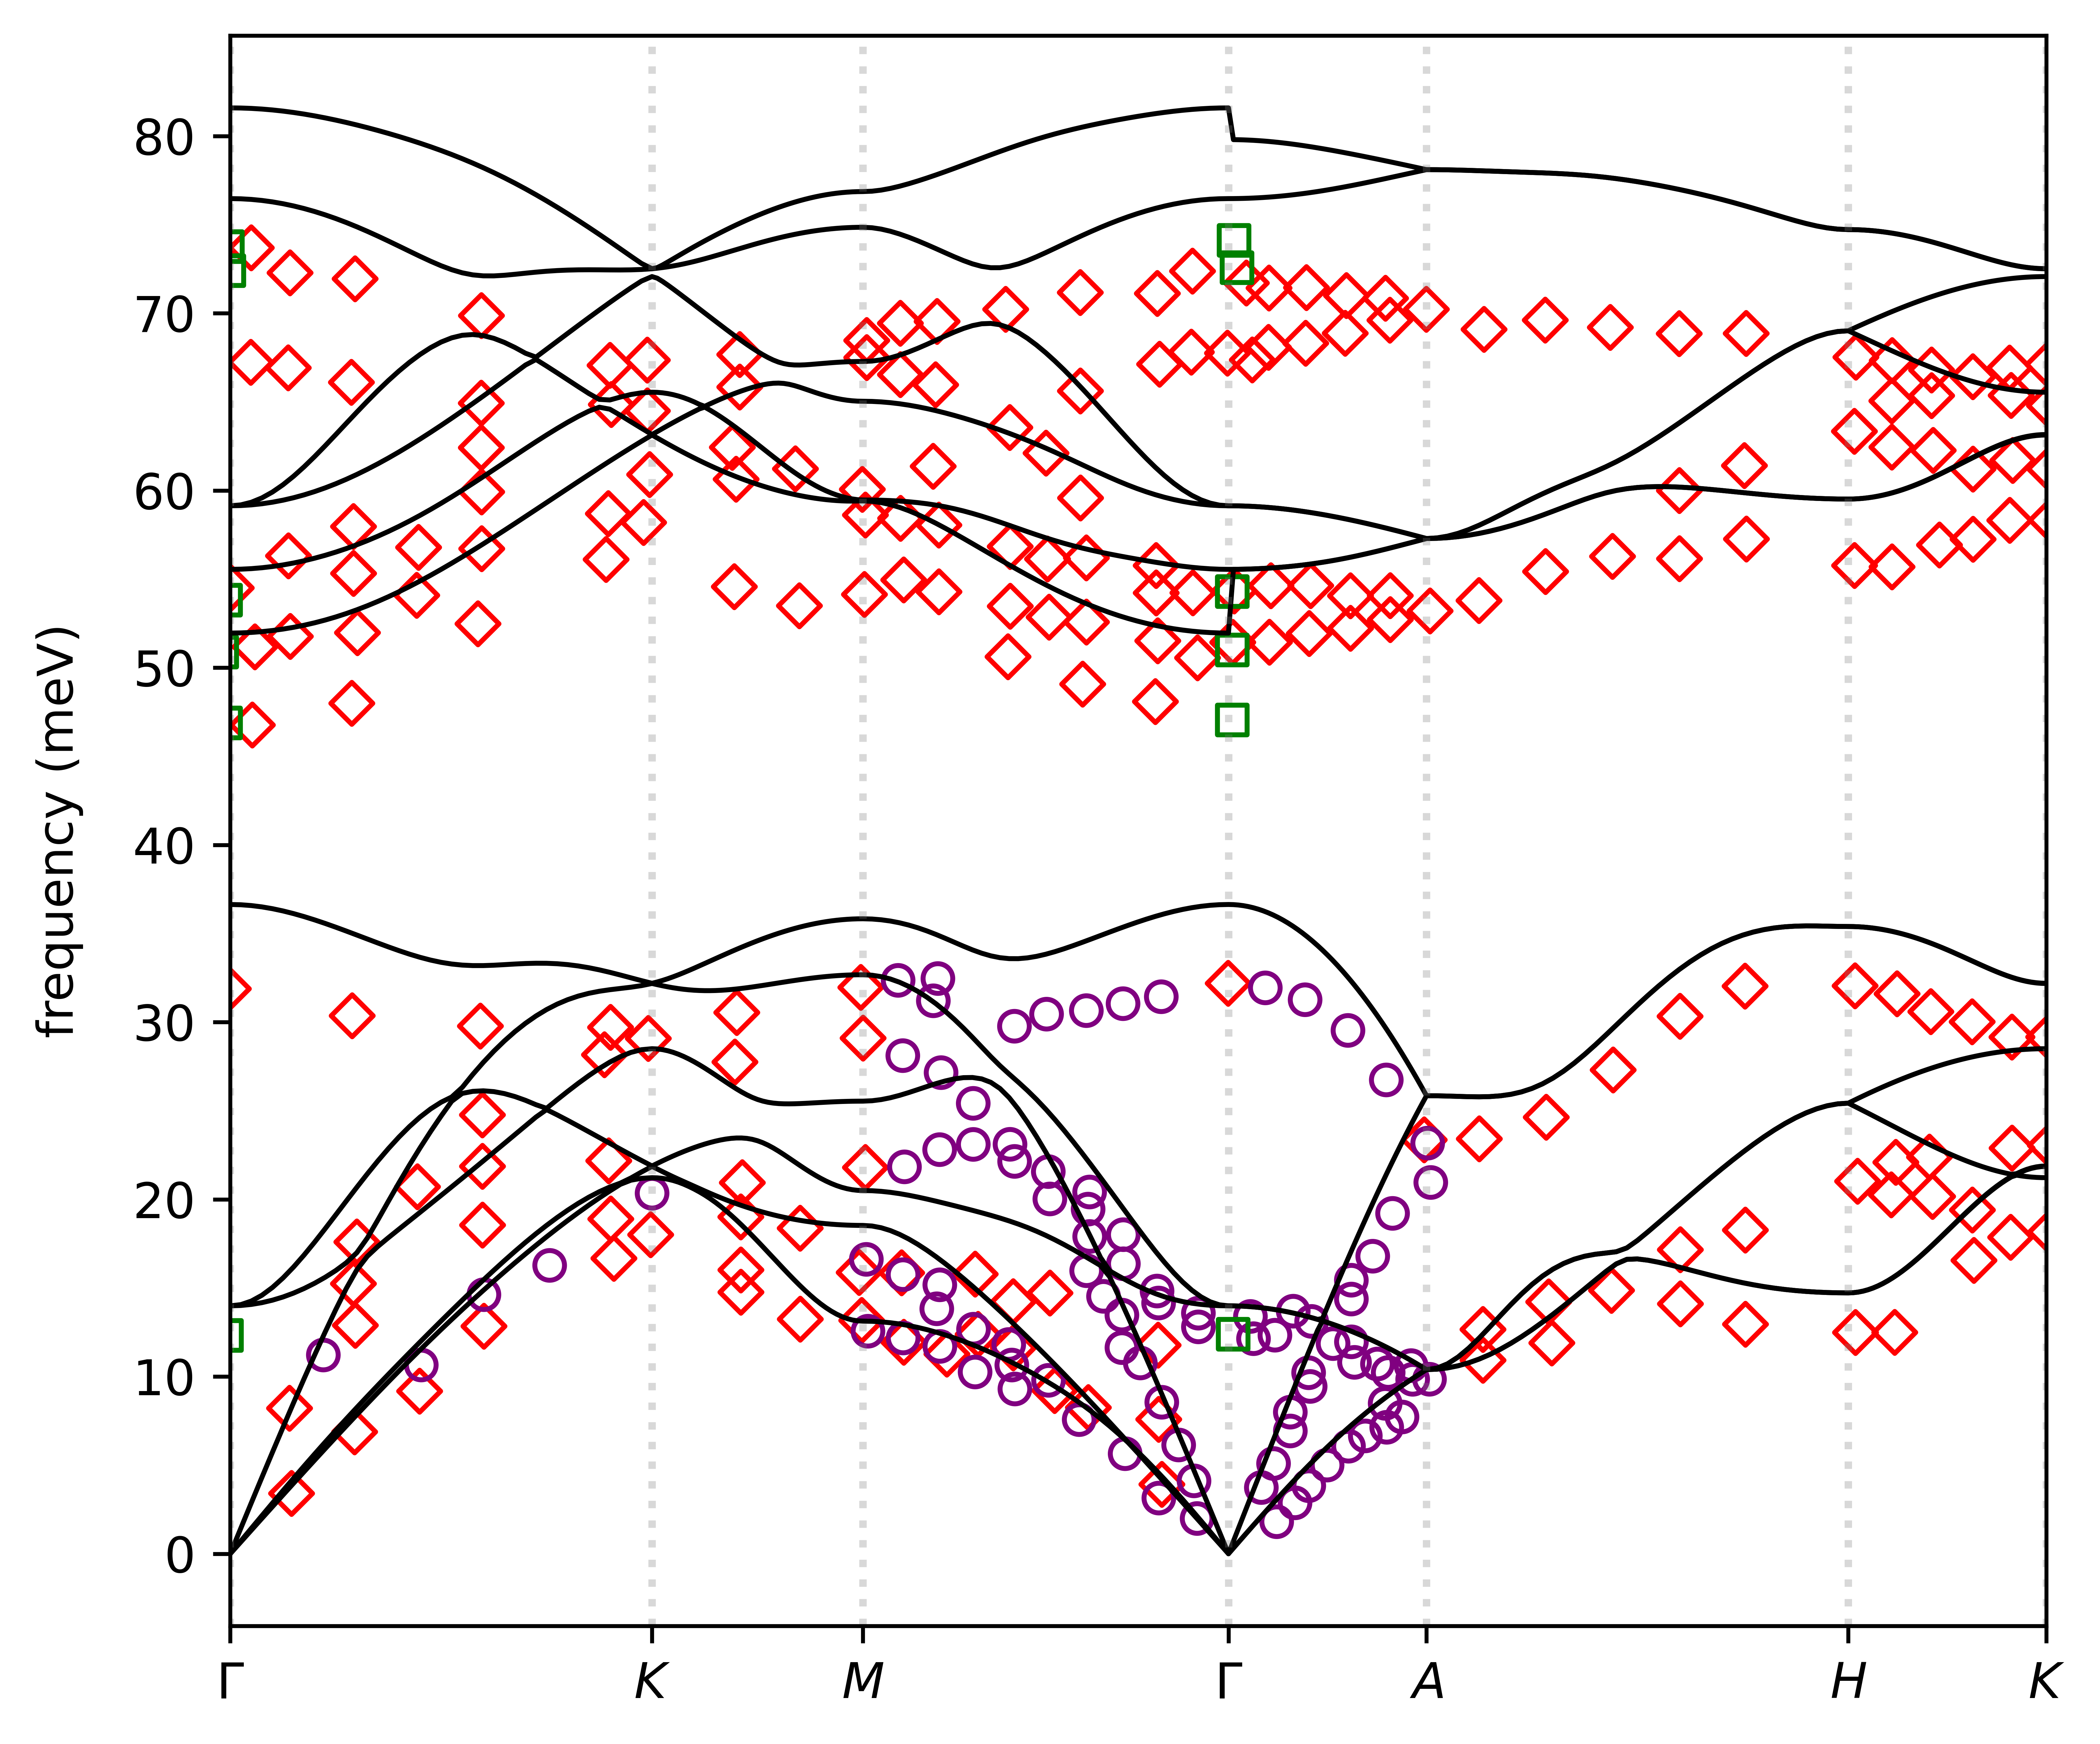

In [ ]:

markers = ['D', 'o', 's']
colors = ['red', 'purple', 'green']

fig, ax = plt.subplots(figsize=(6,5), dpi=1200)

ax.set_ylabel("frequency (meV)", labelpad=10)

ax.set_xlim(q.min(), q.max())
# THEORETICAL DATA

for i in range(freqs_meV.shape[1]):
    plt.plot(q, freqs_meV[:,i], lw=1, color='k')

# EXPERIMENTAL DATA
ii = 0
for df in [df_red, df_purple, df_green]:
    ax.scatter(df['k'], df['freq_meV'], marker=markers[ii], color=colors[ii], facecolors='none')
    ii += 1

# HIGH SYMMETRY 
high_symmetry_points = [q[40*i] for i in range(7)]
for hsp in high_symmetry_points:
    ax.axvline(hsp, c='gray', alpha=0.3, ls=':')
ax.set_xticks(
    ticks = high_symmetry_points,
    labels= [r"$\Gamma$", r"$K$", r"$M$", r"$\Gamma$", r"$A$", r"$H$", r"$K$"]
)

fig.tight_layout()
fig.show()